<a href="https://colab.research.google.com/github/chucholoport/upsrj-machine-learning/blob/develop/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets        import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.metrics        import accuracy_score, classification_report, confusion_matrix

In [7]:
# carga de base de datos
data = load_breast_cancer()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [8]:
# variables para nuestro modelo
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

In [10]:
# división de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [11]:
# creación y entrenamiento del modelo
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [12]:
# predicción
y_pred = model.predict(X_test)

In [16]:
# evaluación
print(f"accuracy score:        \n{accuracy_score(y_test, y_pred)}")
print(f"confusion matrix:      \n{confusion_matrix(y_test, y_pred)}")
print(f"classification report: \n{classification_report(y_test, y_pred)}")

accuracy score:        
0.9239766081871345
confusion matrix:      
[[ 57   7]
 [  6 101]]
classification report: 
              precision    recall  f1-score   support

           0       0.90      0.89      0.90        64
           1       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



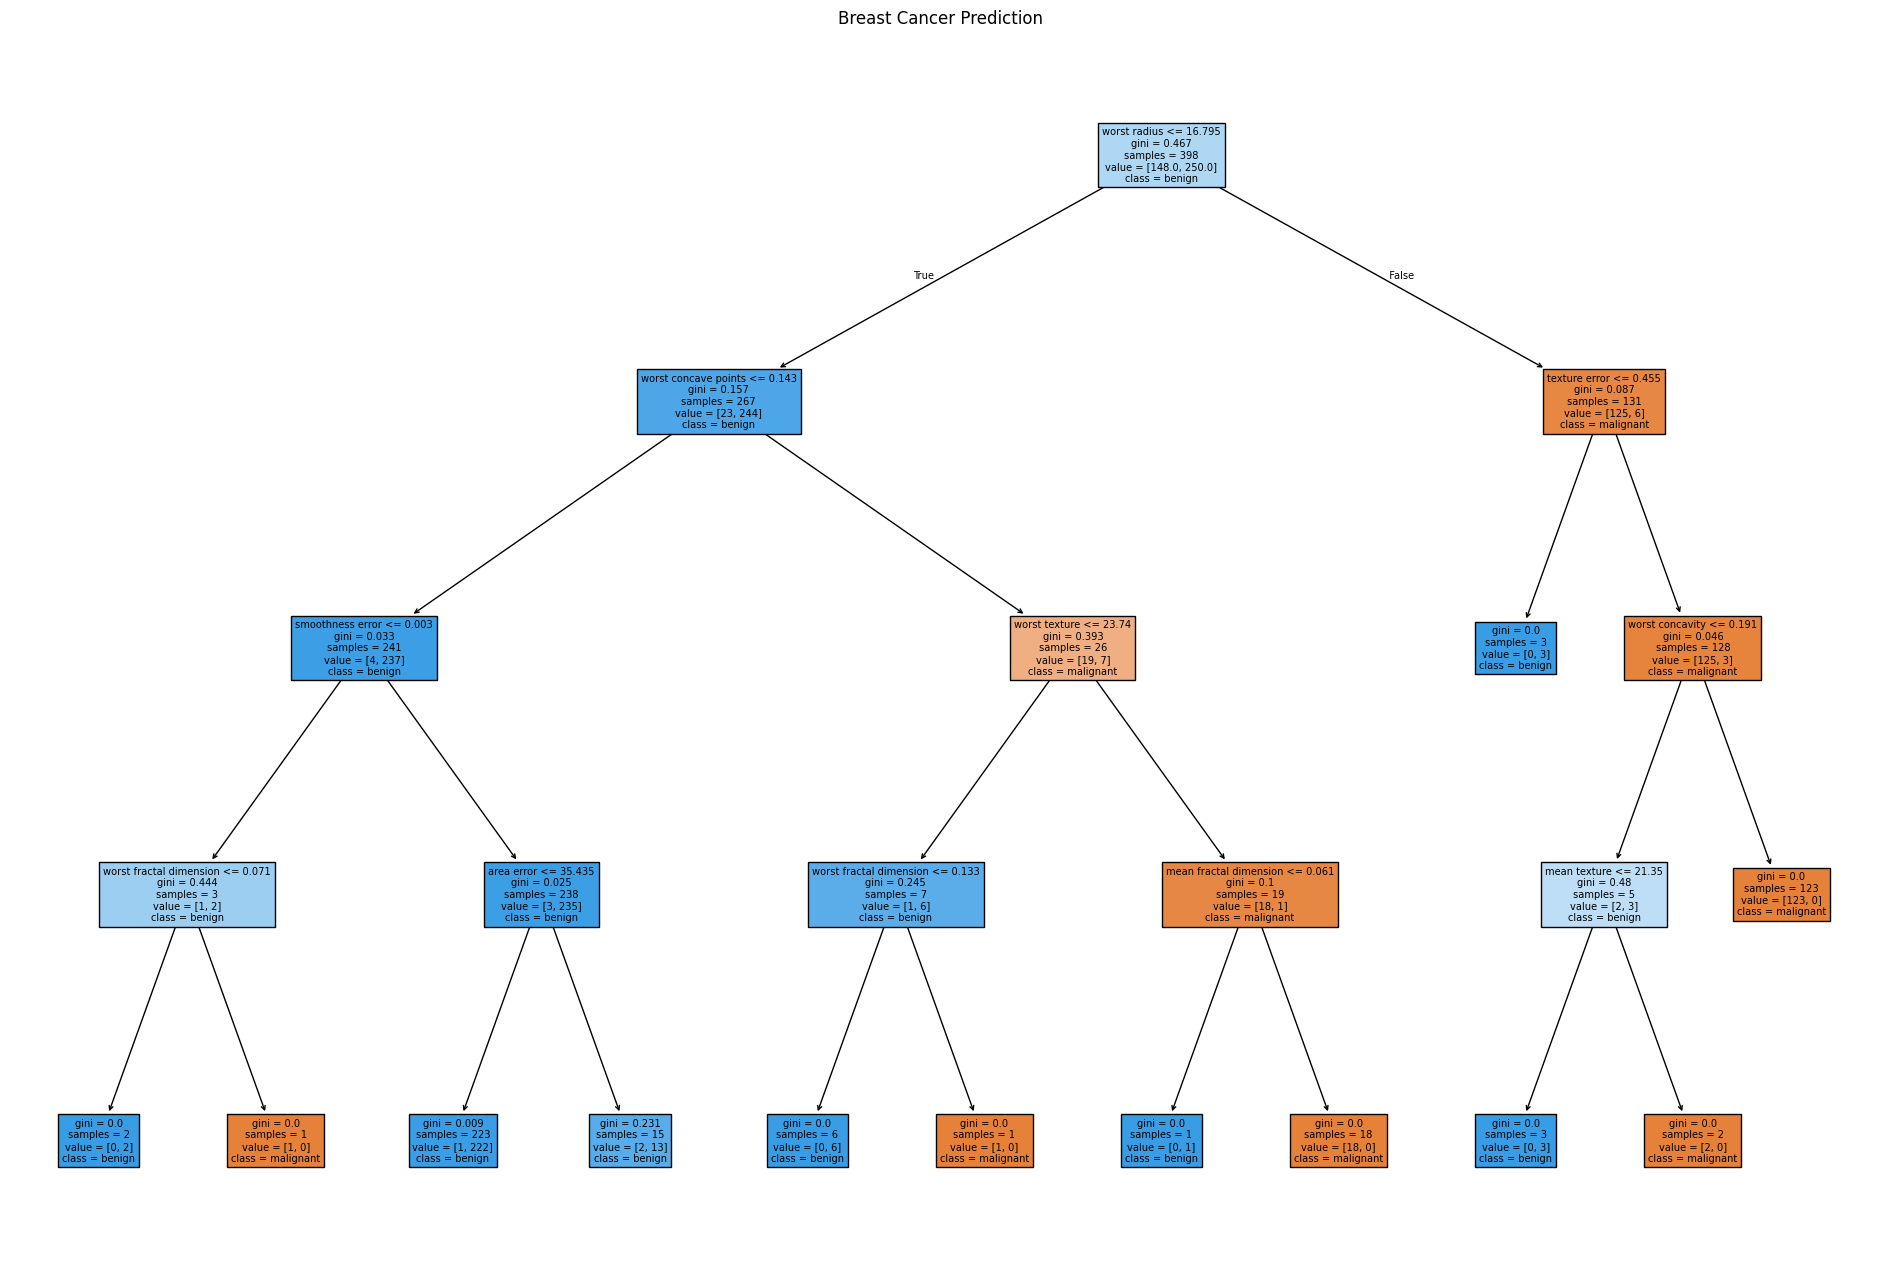

In [21]:
plt.figure(figsize=(24,16))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)
plt.title("Breast Cancer Prediction")
plt.show()